In [1]:
#Version Numbers Used to Generate this Pset:
#seaborn=0.11.2
#scipy==1.8.0
#numpy==1.22.2
#matplotlib==3.5.1

import scipy as sp
from pylab import *
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
import pandas as pd
import seaborn as sns
import collections
from IPython.display import clear_output
import random
import openpyxl
import os 
sns.set_style("ticks")
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pickle

FigureTitle="Figure"

np.random.seed(1)
if not os.path.exists(FigureTitle):

   # Create a new directory because it does not exist
   os.makedirs(FigureTitle)
   print("The new directory is created!")

mm = 0.1/2.54
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/latex'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.4
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.4
mpl.rcParams['ytick.major.width'] = 0.5

plt.rcParams['text.usetex'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

In [2]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

my_cmap = ListedColormap(['#00429d', '#4771b2', '#73a2c6', '#a5d5d8', '#ffffe0', '#ffbcaf', '#f4777f', '#cf3759', '#93003a'], name="my_cmap")
my_cmap_r = my_cmap.reversed()
mpl.colormaps.register(cmap=my_cmap)
mpl.colormaps.register(cmap=my_cmap_r)

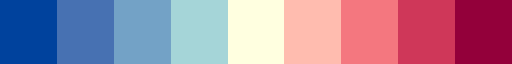

In [3]:
my_cmap

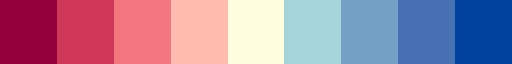

In [4]:
my_cmap_r

In [5]:
def getIDX(data, IDX):
    O = np.flatnonzero([x == IDX for x in data['SampleIDX']])
    return np.array(O)

def getAbundance(Processed_sequences,IDX):
    SampleIdx= np.flatnonzero([x == IDX for x in Processed_sequences['SampleIDX']])
    if not any(SampleIdx):
        return
    else:
        O=Processed_sequences.iloc[SampleIdx].values.tolist()[0][1:]
        return O

def getAbundance_fromList(Processed_sequences,IDX_list):
    IDX_list_=np.squeeze([np.where(Processed_sequences['SampleIDX']==x) for x in IDX_list])
    return (np.array(Processed_sequences.iloc[IDX_list_].values)[:,1:]).astype(float)

def Community_PermutateList_simulation(I,S):
    global Metadata,exception_list
    sample_num=100
    O=(3*(I-1)+(S-1))*100+np.arange(0,100)
    return O

def CommunityPermutate(Timepoint, CommunityOrigin, Medium, CoalescenceType):
    global Metadata
    idx = np.where((Metadata['Timepoint'] == Timepoint) &
                   (Metadata['CommunityOrigin'] == CommunityOrigin) &
                   (Metadata['Medium'] == Medium) &
                   (Metadata['CoalescenceType'] == CoalescenceType))[0]
    O = np.concatenate(Metadata['SampleIDX'][idx])
    return O

def CommunityPermutate_withSpeciesPoolsize(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num):
    global Metadata,exception_list
    idx = (Metadata['Timepoint'] == Timepoint) & \
          (Metadata['CommunityOrigin'] == CommunityOrigin) & \
          (Metadata['Medium'] == Medium) & \
          (Metadata['CoalescenceType'] == CoalescenceType)

    communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
    if CoalescenceType == 'S':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 9)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
    elif CoalescenceType == 'C':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 14)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 41) & (communityIDX <= 47))

    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def Community_PermutateList(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num=0, Replicate=-1):
    global Metadata,exception_list
    
    if Replicate==-1:
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType)
    elif Replicate == 1 or Replicate == 2 : 
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType) & \
              (Metadata['Replicate'] == Replicate)
    else : 
        raise ValueError("Invalid input")

    
    if CommunityOrigin=='S':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        if CoalescenceType == 'S':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 9)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
            elif species_pool_num ==0:
                idx = idx
        elif CoalescenceType == 'C':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 14)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 41) & (communityIDX <= 47))
            elif species_pool_num ==0:
                idx = idx
    elif CommunityOrigin=='N':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        
    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def getCommunities(Communities_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Communities_data['SampleIDX']==x) for x in IDX_list])
    return (Communities_data.iloc[IDX_list_])

def getCoalescence(Coalescence_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])#IDX_list_
    return (Coalescence_data.iloc[IDX_list_])

Coalescence_data_synthetic_path ="../../Analyzed/processed_CoalescenceEvent_synthetic.xlsx"
Communities_data_synthetic_path ="../../Analyzed/processed_Communities_synthetic.xlsx"
Coalescence_data_natural_path ="../../Analyzed/processed_CoalescenceEvent_natural.xlsx"
Communities_data_natural_path ="../../Analyzed/processed_Communities_natural.xlsx"
Coalescence_recipe_path="../../Postprocessed/CoalescenceRecipe.xlsx"
Meta_data_path="../../Postprocessed/Metadata.xlsx"
Processed_sequences_synthetic_path="../../Postprocessed/processed_Sequences_synthetic.xlsx"
Processed_sequences_natural_path="../../Postprocessed/processed_Sequences_natural.xlsx"
Coalescence_data_sim_path="../../Analyzed/processed_CoalescenceEvent_simulation_uniform.xlsx"
#Communities_data_sim_path="Analyzed/processed_Communities_simulation_uniform.xlsx"

Coalescence_data=pd.concat([pd.read_excel(Coalescence_data_synthetic_path),pd.read_excel(Coalescence_data_natural_path)])
Communities_data=pd.concat([pd.read_excel(Communities_data_synthetic_path),pd.read_excel(Communities_data_natural_path)])
Coalescence_data_sim=pd.read_excel(Coalescence_data_sim_path)
#Communities_data_sim=pd.read_excel(Communities_data_sim_path)

Coalescence_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=0)
Coalescence_natural_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=1)
Metadata=pd.read_excel(Meta_data_path)
Processed_sequences_synthetic=pd.read_excel(Processed_sequences_synthetic_path)
Processed_sequences_natural=pd.read_excel(Processed_sequences_natural_path)

exception_list=['P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12']+['P8-91'] + ['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] + ['P5-47', 'P5-50'] + ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57']
#'P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12' : These cases are for no reads in coalescence result
# 'P8-91' : no file
#['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] : MN E7 is missing
# 'P6-67' : is too low reads( 500)
# 'P5-47', 'P5-50' : MN24 CC, too much unwanted ASVs(maybe due to wrong labeling)
# ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57'] : ASV not in sub 2> 0.3

I = [0.33, 0.66, 0.99]
species_pools = [6, 12, 24]
sample_num=100
Syn_Simulation_IDX = {
    "I1_S1": Community_PermutateList_simulation(1,1),
    "I1_S2": Community_PermutateList_simulation(1,2),
    "I1_S3": Community_PermutateList_simulation(1,3),
    "I2_S1": Community_PermutateList_simulation(2,1),
    "I2_S2": Community_PermutateList_simulation(2,2),
    "I2_S3": Community_PermutateList_simulation(2,3),
    "I3_S1": Community_PermutateList_simulation(3,1),
    "I3_S2": Community_PermutateList_simulation(3,2),
    "I3_S3": Community_PermutateList_simulation(3,3),
}
mediums_pools = ["LN", "MN", "HN"]
species_pools = [6, 12, 24]
Syn_Coal_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "C", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "C", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "C", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "C", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "C", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "C", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "C", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "C", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "C", 24)
}
Syn_Sub_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "S", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "S", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "S", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "S", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "S", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "S", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "S", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "S", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "S", 24)
}
Nat_Coal_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "C"),
    "MN": Community_PermutateList("F", "N", "M", "C"),
    "HN": Community_PermutateList("F", "N", "H", "C")
}
Nat_Sub_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "S"),
    "MN": Community_PermutateList("F", "N", "M", "S"),
    "HN": Community_PermutateList("F", "N", "H", "S")
}




In [6]:
def pHcriteria(pH_list,return_type="Num"):
    pH_list=np.array(pH_list)
    O=1*(pH_list>6)+1*(pH_list>8)
    if return_type=="Num":
        return O
    if return_type=="Word":
        word_list=['acidic','neutral','alkalic']
        return [word_list[x] for x in O]
    if return_type=="Color":
        word_list=['r','g','b']
        return [word_list[x] for x in O]

def getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list):
    N=len(Sub_IDX_list)
    matrix={Sub_IDX : {} for Sub_IDX in Sub_IDX_list }
    for SampleIDX in Coal_IDX_list:
        idx=np.where(Coalescence_data['SampleIDX']==SampleIDX)
        dominance1=Coalescence_data.iloc[idx][Variable2plot].tolist()[0]
        dominance2=1-dominance1
        subSampleIDX1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()[0]
        #subidx1=np.where(Sub_IDX_list==subSmapleIDX1)
        subSampleIDX2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()[0]


        #subidx2=np.where(Sub_IDX_list==subSmapleIDX2)
        matrix[subSampleIDX1].update({subSampleIDX2:dominance1})
        matrix[subSampleIDX2].update({subSampleIDX1:dominance2})
    for SampleIDX in Sub_IDX_list:
        matrix[SampleIDX].update({SampleIDX:0.5})
    
    return matrix   

def EstimateErrorLassoRegression(IDX_list, x, y, order, alpha, beta, preprocess='Basic', verbose=False):
    communityIDX_list=np.unique(getCommunities(Communities_data,IDX_list)['CommunityIDX'])
    train_mse_list=[]
    test_mse_list=[]
    
    if preprocess=='Basic':
        y_tofit=y.copy()
    elif preprocess=='Normalize':
        y_tofit=(y.copy()-0.5)*2
    elif preprocess=='Tan':
        y_tofit=np.tan((y.copy()-0.5)*np.pi/2)
        
    for communityID_toTest in communityIDX_list:  
        getCommunities(Communities_data,Community_PermutateList("F", com_type, medium, "S", species_num, rep))
        train_idx_list=np.where(getCommunities(Communities_data,IDX_list)['CommunityIDX']!=communityID_toTest)[0]
        test_idx_list=np.where(getCommunities(Communities_data,IDX_list)['CommunityIDX']==communityID_toTest)[0]

        # Generate synthetic data
        X_train = beta*x[train_idx_list,:]
        y_train = y_tofit[train_idx_list]#y[:]
        X_test = beta*x[test_idx_list,:]
        y_test = y_tofit[test_idx_list]
        # Split data into training and testing sets
        
        # Transform features to include up to second-order terms
        polynomial_features = PolynomialFeatures(degree=order, include_bias=True)
        X_train_poly = polynomial_features.fit_transform(X_train)
        X_test_poly = polynomial_features.transform(X_test)

        # Create the model
        model = Lasso(alpha=alpha, max_iter = 1000)

        # Fit the model to the training data
        model.fit(X_train_poly, y_train)

        # Predict the target values for the test set
        y_pred_train = model.predict(X_train_poly)
        y_pred_test = model.predict(X_test_poly)

        # Evaluate the model
        train_mse = np.mean((y_train-y_pred_train)**2)
        test_mse = np.mean((y_test-y_pred_test)**2)
        ref_mse= np.var(y_tofit)
        if verbose:
            print(f'Mean Train Squared Error: {train_mse}')
            print(f'Mean Test Squared Error: {test_mse, y_test, y_pred_test}')
        plt.scatter(y_test,y_pred_test)
        train_mse_list.append(train_mse/ref_mse)
        test_mse_list.append(test_mse/ref_mse)
    return communityIDX_list, train_mse_list, test_mse_list
    

########################################################
########################################################
# Fig 1-1
########################################################
########################################################

##~~~~~~~~~~~~~~ This figure is cartoon ~~~~~~~~~~~~~~##

In [7]:
IDX_list=np.sort(Community_PermutateList("F", "S", "M", "C", 12, 1))
IDX_list[10]

'P5-25'

########################################################
########################################################
# Fig 1-2
########################################################
########################################################

##~~~~~~~~~~~~~~ This figure is cartoon ~~~~~~~~~~~~~~##

########################################################
########################################################
# Fig 1-3
########################################################
########################################################


In [8]:
sns.color_palette("Set2",10)

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254),
 (0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961)]

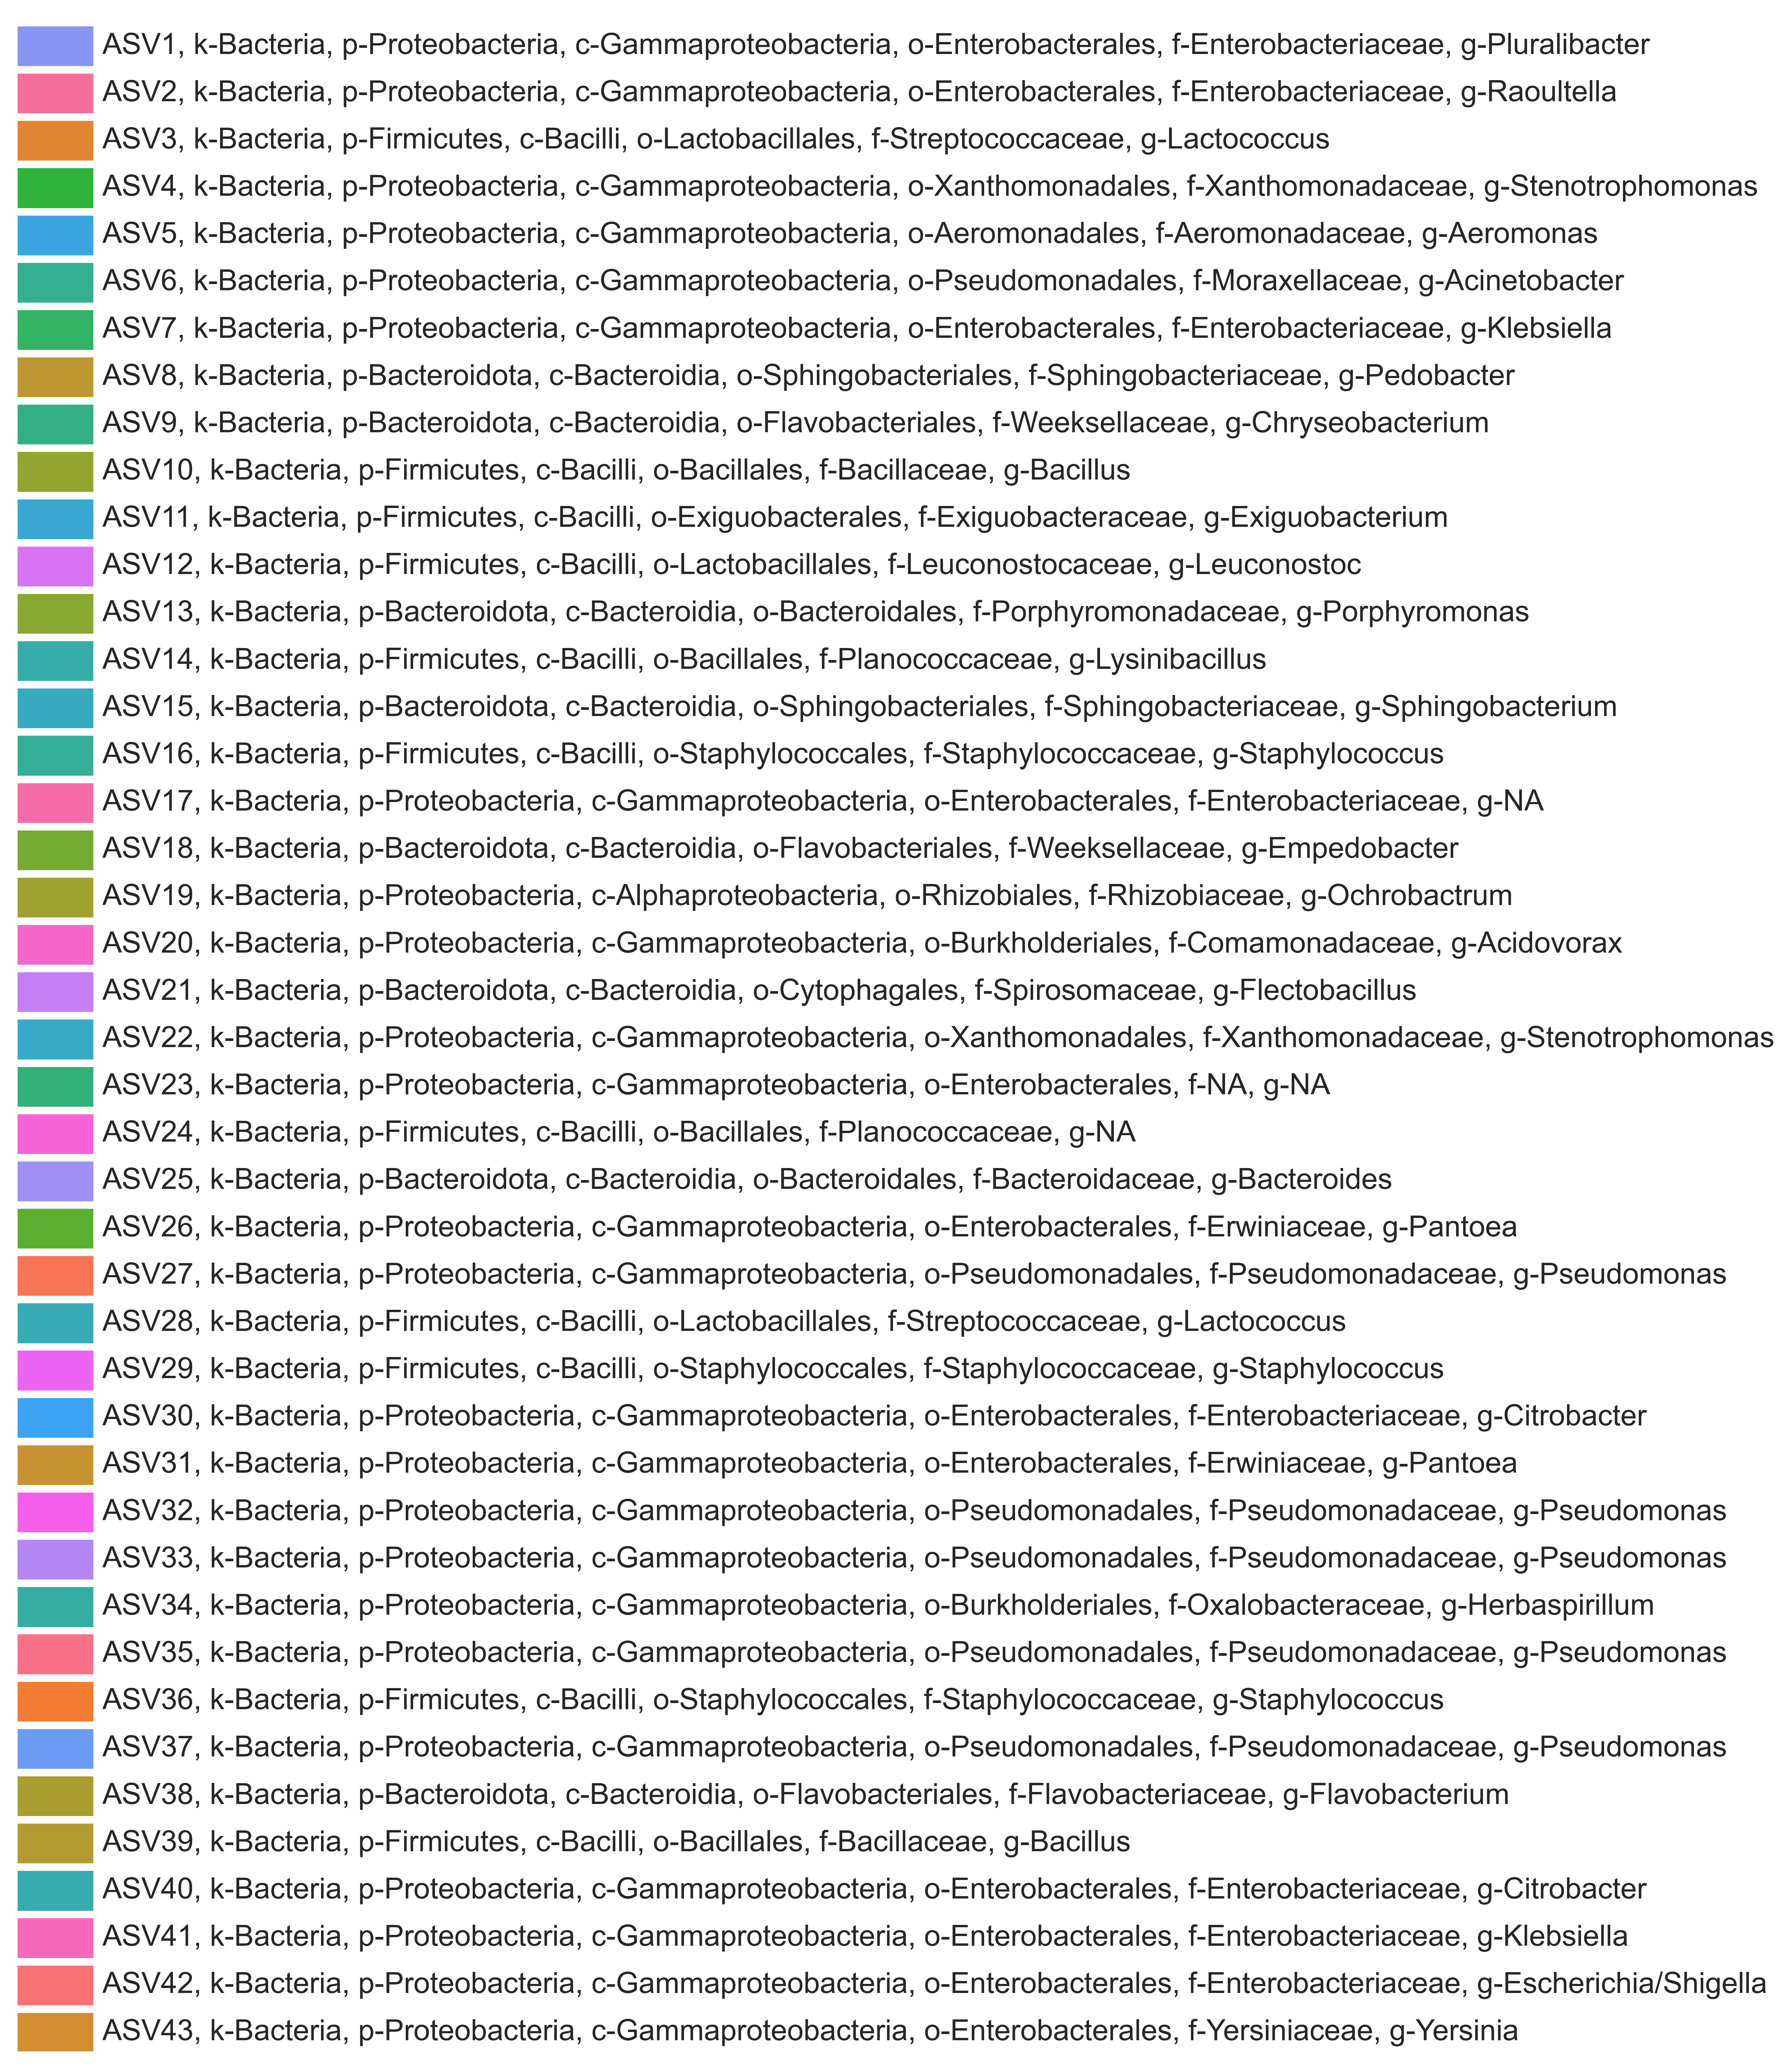

In [9]:
def settingTheColor(seed=4):
    np.random.seed(seed)  # Set the seed for reproducibility
    cm = sns.color_palette("husl", 43)  # Generate a color palette with 43 colors
    np.random.shuffle(cm)  # Shuffle the colormap directly
    return cm


# Sample data (replace with your own)
data = [
    ["ASV1", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Enterobacterales", "Enterobacteriaceae", "Pluralibacter"],
    ["ASV2", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Enterobacterales", "Enterobacteriaceae", "Raoultella"],
    ["ASV3", "Bacteria", "Firmicutes", "Bacilli", "Lactobacillales", "Streptococcaceae", "Lactococcus"],
    ["ASV4", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Xanthomonadales", "Xanthomonadaceae", "Stenotrophomonas"],
    ["ASV5", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Aeromonadales", "Aeromonadaceae", "Aeromonas"],
    ["ASV6", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Pseudomonadales", "Moraxellaceae", "Acinetobacter"],
    ["ASV7", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Enterobacterales", "Enterobacteriaceae", "Klebsiella"],
    ["ASV8", "Bacteria", "Bacteroidota", "Bacteroidia", "Sphingobacteriales", "Sphingobacteriaceae", "Pedobacter"],
    ["ASV9", "Bacteria", "Bacteroidota", "Bacteroidia", "Flavobacteriales", "Weeksellaceae", "Chryseobacterium"],
    ["ASV10", "Bacteria", "Firmicutes", "Bacilli", "Bacillales", "Bacillaceae", "Bacillus"],
    ["ASV11", "Bacteria", "Firmicutes", "Bacilli", "Exiguobacterales", "Exiguobacteraceae", "Exiguobacterium"],
    ["ASV12", "Bacteria", "Firmicutes", "Bacilli", "Lactobacillales", "Leuconostocaceae", "Leuconostoc"],
    ["ASV13", "Bacteria", "Bacteroidota", "Bacteroidia", "Bacteroidales", "Porphyromonadaceae", "Porphyromonas"],
    ["ASV14", "Bacteria", "Firmicutes", "Bacilli", "Bacillales", "Planococcaceae", "Lysinibacillus"],
    ["ASV15", "Bacteria", "Bacteroidota", "Bacteroidia", "Sphingobacteriales", "Sphingobacteriaceae", "Sphingobacterium"],
    ["ASV16", "Bacteria", "Firmicutes", "Bacilli", "Staphylococcales", "Staphylococcaceae", "Staphylococcus"],
    ["ASV17", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Enterobacterales", "Enterobacteriaceae", "NA"],
    ["ASV18", "Bacteria", "Bacteroidota", "Bacteroidia", "Flavobacteriales", "Weeksellaceae", "Empedobacter"],
    ["ASV19", "Bacteria", "Proteobacteria", "Alphaproteobacteria", "Rhizobiales", "Rhizobiaceae", "Ochrobactrum"],
    ["ASV20", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Burkholderiales", "Comamonadaceae", "Acidovorax"],
    ["ASV21", "Bacteria", "Bacteroidota", "Bacteroidia", "Cytophagales", "Spirosomaceae", "Flectobacillus"],
    ["ASV22", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Xanthomonadales", "Xanthomonadaceae", "Stenotrophomonas"],
    ["ASV23", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Enterobacterales", "NA", "NA"],
    ["ASV24", "Bacteria", "Firmicutes", "Bacilli", "Bacillales", "Planococcaceae", "NA"],
    ["ASV25", "Bacteria", "Bacteroidota", "Bacteroidia", "Bacteroidales", "Bacteroidaceae", "Bacteroides"],
    ["ASV26", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Enterobacterales", "Erwiniaceae", "Pantoea"],
    ["ASV27", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Pseudomonadales", "Pseudomonadaceae", "Pseudomonas"],
    ["ASV28", "Bacteria", "Firmicutes", "Bacilli", "Lactobacillales", "Streptococcaceae", "Lactococcus"],
    ["ASV29", "Bacteria", "Firmicutes", "Bacilli", "Staphylococcales", "Staphylococcaceae", "Staphylococcus"],
    ["ASV30", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Enterobacterales", "Enterobacteriaceae", "Citrobacter"],
    ["ASV31", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Enterobacterales", "Erwiniaceae", "Pantoea"],
    ["ASV32", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Pseudomonadales", "Pseudomonadaceae", "Pseudomonas"],
    ["ASV33", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Pseudomonadales", "Pseudomonadaceae", "Pseudomonas"],
    ["ASV34", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Burkholderiales", "Oxalobacteraceae", "Herbaspirillum"],
    ["ASV35", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Pseudomonadales", "Pseudomonadaceae", "Pseudomonas"],
    ["ASV36", "Bacteria", "Firmicutes", "Bacilli", "Staphylococcales", "Staphylococcaceae", "Staphylococcus"],
    ["ASV37", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Pseudomonadales", "Pseudomonadaceae", "Pseudomonas"],
    ["ASV38", "Bacteria", "Bacteroidota", "Bacteroidia", "Flavobacteriales", "Flavobacteriaceae", "Flavobacterium"],
    ["ASV39", "Bacteria", "Firmicutes", "Bacilli", "Bacillales", "Bacillaceae", "Bacillus"],
    ["ASV40", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Enterobacterales", "Enterobacteriaceae", "Citrobacter"],
    ["ASV41", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Enterobacterales", "Enterobacteriaceae", "Klebsiella"],
    ["ASV42", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Enterobacterales", "Enterobacteriaceae", "Escherichia/Shigella"],
    ["ASV43", "Bacteria", "Proteobacteria", "Gammaproteobacteria", "Enterobacterales", "Yersiniaceae", "Yersinia"]
]
# Sample list of 42 color values (replace with your own)
color_map = settingTheColor()
color_map = color_map[::-1]

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 15))

# Define the width and height of each color block
block_width = 0.015  # Smaller block width

# Define the initial position for drawing color blocks
y = 0

# Define the interval between rectangles and text (smaller spacing)
spacing = 0.004

# Loop through the data to draw color blocks and text
for i, row in enumerate(data[::-1]):
    species = row[0]
    taxonomy = row[1:]
    
    # Find the index of the taxonomy in the list of color_map
    taxonomy_hash = hash("".join(taxonomy))  # Combine taxonomy elements into a single string for hashing
    taxonomy_index = abs(taxonomy_hash) % len(color_map)
    color = color_map[i]

    # Draw a color block
    ax.add_patch(plt.Rectangle((0, y), block_width*2, block_width, color=color))

    # Add species taxonomy text on the right side with reduced spacing
    formatted_taxonomy = [f"{level[0]}-{level[1]}" for level in zip("kpcofg", taxonomy)]
    text = species+', '+ ", ".join(formatted_taxonomy)
    ax.text(block_width*2 + spacing, y + 0.5 * block_width, text, va='center', fontsize=12)

    # Update the position for the next color block
    y += block_width + spacing  # Adjust the spacing

# Set the aspect ratio and axis limits
ax.set_aspect('equal')
ax.set_xlim(0, block_width + 0.1)
ax.set_ylim(0, y)

# Remove axis labels and ticks
ax.axis('off')

# Save the SVG file
plt.savefig('Figure/taxonomy_color_map.svg', format='svg', bbox_inches='tight')
plt.show()

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_17374/574275754.py:53: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  f.show()
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_17374/574275754.py:99: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  f.show()


<Figure size 3840x2880 with 0 Axes>

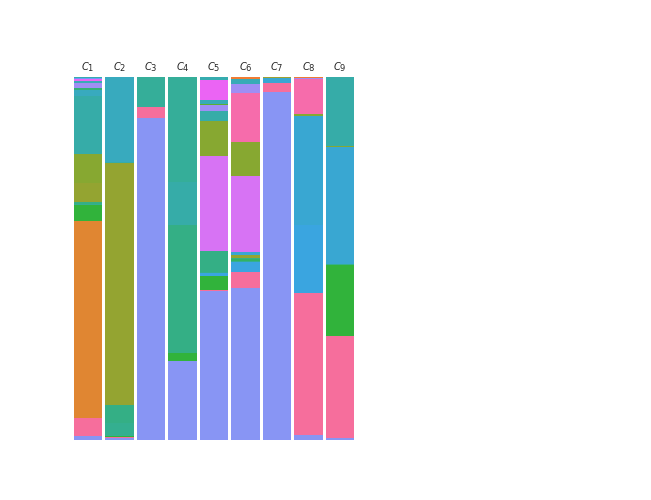

<Figure size 3840x2880 with 0 Axes>

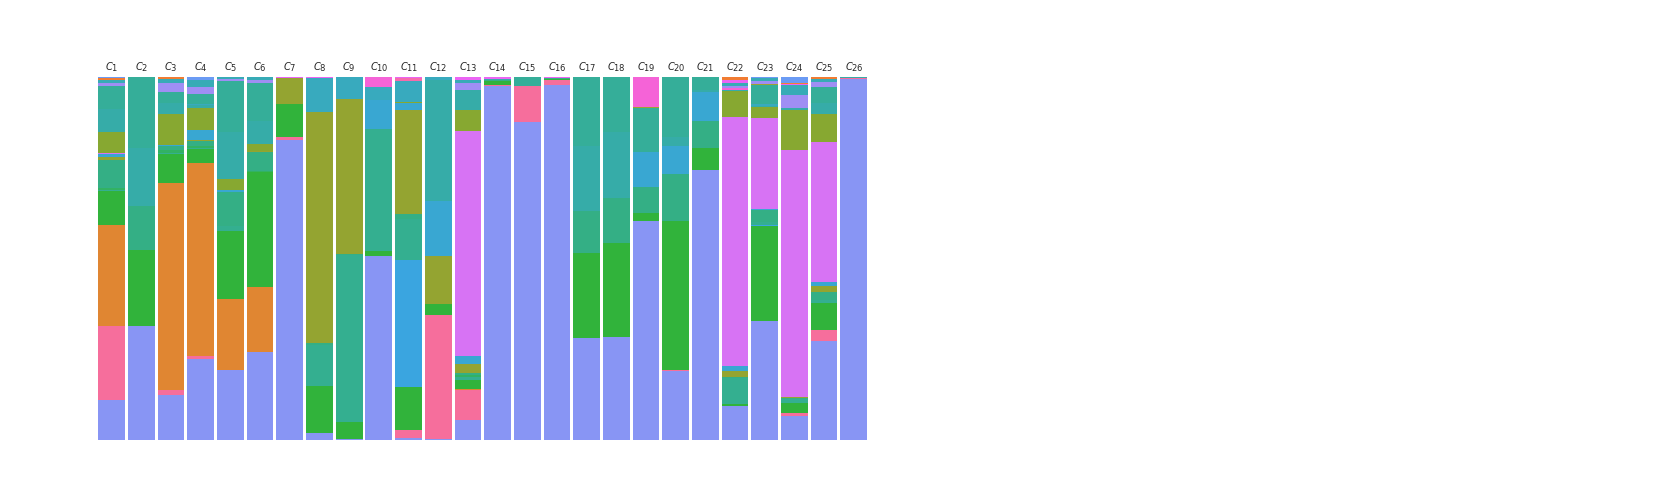

In [10]:
########################################################
########################################################
# Fig 1-3
########################################################
########################################################

## This figure gives Full data of MN, 12 species
from cycler import cycler


if True : 
    fig=figure(num=None)
    IDX_list=np.sort(Community_PermutateList("F", "S", "M", "S", 12, 1))

    IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
    df=Processed_sequences_synthetic.iloc[IDX_list_]

    color_map = settingTheColor()

    degList = [i for i in df.columns if i[0:4]=='Norm']
    degList_ = [i.replace('NormalizedAbundance','ASV') for i in degList]
    bar_l = np.array(range(df.shape[0]))

    #cm = plt.get_cmap('viridis',42)

    f, ax = plt.subplots(1, figsize=(len(IDX_list)*4*mm,8*4*mm), facecolor='w', edgecolor='k')

    x_scale=0.5
    bottom = np.zeros_like(bar_l).astype('float')
    for i, deg in enumerate(degList):
        ax.bar(bar_l*x_scale, df[deg],width=0.9*x_scale,bottom = bottom, label=degList_[i],linewidth=0, color= color_map[i])
        bottom += df[deg].values
        #for j, val in enumerate(df[deg]):
            #if val>0.01:
                #ax.text(j*x_scale, bottom[j]-df[deg].tolist()[j]/2, 'ASV'+str(i+1), ha='center', va='center', fontsize=.8, color="white")

    for i, IDX in enumerate(df['SampleIDX'].tolist()):
        ax.text(bar_l[i]*x_scale, 1.01, "$C_{"+str(i+1)+"}$", ha='center', va='bottom', fontsize=1.2)

    ax.set_xticks(bar_l)
    #ax.set_xticklabels(df['INSTNM'].values, rotation=90, size='x-small')
    #ax.legend(loc="upper left", bbox_to_anchor=(1,1), ncol=2, fontsize='x-small')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.get_xaxis().set_ticks([])
    ax.get_yaxis().set_ticks([])

    f.subplots_adjust(right=0.75, bottom=0.4)

    f.show()
    f.savefig(FigureTitle + '/Fig_1-3_compositionDiagram_subcomm_rep1.svg', bbox_inches='tight')
    #plt.close(f)

if True : 
    fig=figure(num=None)
    IDX_list=np.sort(Community_PermutateList("F", "S", "M", "C", 12, 1))

    IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
    df=Processed_sequences_synthetic.iloc[IDX_list_]

    color_map = settingTheColor()

    degList = [i for i in df.columns if i[0:4]=='Norm']
    degList_ = [i.replace('NormalizedAbundance','ASV') for i in degList]
    bar_l = np.array(range(df.shape[0]))

    #cm = plt.get_cmap('viridis',42)

    f, ax = plt.subplots(1, figsize=(len(IDX_list)*4*mm,8*4*mm), facecolor='w', edgecolor='k')

    x_scale=0.5
    bottom = np.zeros_like(bar_l).astype('float')
    for i, deg in enumerate(degList):
        ax.bar(bar_l*x_scale, df[deg],width=0.9*x_scale,bottom = bottom, label=degList_[i],linewidth=0, color= color_map[i])
        bottom += df[deg].values
        #for j, val in enumerate(df[deg]):
            #if val>0.01:
                #ax.text(j*x_scale, bottom[j]-df[deg].tolist()[j]/2, 'ASV'+str(i+1), ha='center', va='center', fontsize=.8, color="white")

    for i, IDX in enumerate(df['SampleIDX'].tolist()):
        ax.text(bar_l[i]*x_scale, 1.01, "$C_{"+str(i+1)+"}$", ha='center', va='bottom', fontsize=1.2)

    ax.set_xticks(bar_l)
    #ax.set_xticklabels(df['INSTNM'].values, rotation=90, size='x-small')
    #ax.legend(loc="upper left", bbox_to_anchor=(1,1), ncol=2, fontsize='x-small')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.get_xaxis().set_ticks([])
    ax.get_yaxis().set_ticks([])

    f.subplots_adjust(right=0.75, bottom=0.4)

    f.show()
    f.savefig(FigureTitle + '/Fig_1-3_compositionDiagram_mixed_rep1.svg', bbox_inches='tight')
    #plt.close(f)

In [11]:
# MN Pair
# D2+D8->B12
# G5+G6->D9
# G9+G10->D11

##MC SC12
IDX_list_D2=['P1-10', 'P1-11', 'P1-12', 'P1-34', 'P1-35', 'P1-36']
IDX_list_D8=['P1-22', 'P1-23', 'P1-24', 'P1-46', 'P1-47', 'P1-48']

## MN CC12
IDX_list_B12=['P8-34', 'P8-35', 'P8-36', 'P8-70', 'P8-71', 'P8-72']

## MN CC24
IDX_list_D9=['P8-46', 'P8-47', 'P8-48', 'P8-82', 'P8-83', 'P8-84']
IDX_list_D11=['P8-58', 'P8-59', 'P8-60', 'P8-94', 'P8-95', 'P8-96']

##MN SC24
IDX_list_G9=['P2-22', 'P2-23', 'P2-24', 'P2-70', 'P2-71', 'P2-72']
IDX_list_G5=['P2-10', 'P2-11', 'P2-12', 'P2-58', 'P2-59', 'P2-60']
IDX_list_G10=['P2-46', 'P2-47', 'P2-48', 'P2-94', 'P2-95', 'P2-96']
IDX_list_G6=['P2-34', 'P2-35', 'P2-36', 'P2-82', 'P2-83', 'P2-84']

##LN
# A1+A2->A6
# A3+A4->A5
IDX_list_A1 =    ['P3-07', 'P3-08', 'P3-09', 'P3-10', 'P3-11', 'P3-12']
IDX_list_A2 =    ['P3-19', 'P3-20', 'P3-21', 'P3-22', 'P3-23', 'P3-24']
IDX_list_A3 =    ['P3-31', 'P3-32', 'P3-33', 'P3-34', 'P3-35', 'P3-36','P2-63']
IDX_list_A4 =    ['P3-43', 'P3-44', 'P3-45', 'P3-46', 'P3-47', 'P3-48','P2-64']
IDX_list_A5 =    ['P3-55', 'P3-56', 'P3-57', 'P3-58', 'P3-59', 'P3-60']
IDX_list_A6 =    ['P3-67', 'P3-68', 'P3-69', 'P3-70', 'P3-71', 'P3-72', 'P4-53']

# LN Pair
# A3+A4->A6
# 

##HN

IDX_list_B1 =    ['P8-01', 'P8-02','P8-03', 'P8-04','P8-05', 'P8-06']
IDX_list_B2 =    ['P8-13',  'P8-15', 'P8-16', 'P8-17', 'P8-18']
IDX_list_B3 =    ['P8-25', 'P8-26', 'P8-27', 'P8-28', 'P8-29', 'P8-30']
IDX_list_B4 =    ['P8-31', 'P8-32', 'P8-33', 'P8-34', 'P8-35', 'P8-36']
IDX_list_B5 =    ['P8-07', 'P8-08', 'P8-09', 'P8-10', 'P8-11', 'P8-12']
IDX_list_B6 =    ['P8-19', 'P8-20', 'P8-21', 'P8-22', 'P8-23', 'P8-24']


mask

In [12]:
def plot_timeseries_sub(IDX_list,mask):
    fig=figure(num=None)
    IDX_list=IDX_list
    np.random.seed(42)
    IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
    df=Processed_sequences_synthetic.iloc[IDX_list_]
    
    new_row = {
        "SampleIDX": "Randi",  # You can provide a unique label for the new row
    }

    random_initial_value=np.random.rand(43)*mask
    random_initial_value=random_initial_value/sum(random_initial_value)
    # Generate random values for "NormalizedAbundance1" to "NormalizedAbundance43"
    for i in range(1, 44):
        column_name = f"NormalizedAbundance{i}"
        new_row[column_name] = random_initial_value[i-1]

    new_row_df = pd.DataFrame([new_row])

    # Prepend the new row to the existing DataFrame
    df = pd.concat([new_row_df, df], ignore_index=True)


    color_map = settingTheColor()

    degList = [i for i in df.columns if i[0:4]=='Norm']
    degList_ = [i.replace('NormalizedAbundance','ASV') for i in degList]
    bar_l = np.array(range(df.shape[0]))

    #cm = plt.get_cmap('viridis',42)

    f, ax = plt.subplots(1, figsize=(len(IDX_list)*3*mm,8*4*mm), facecolor='w', edgecolor='k')

    x_scale=0.5
    bottom = np.zeros_like(bar_l).astype('float')
    for i, deg in enumerate(degList):
        ax.bar(bar_l*x_scale, df[deg],width=0.9*x_scale,bottom = bottom, label=degList_[i],linewidth=0, color= color_map[i])
        bottom += df[deg].values
        #for j, val in enumerate(df[deg]):
            #if val>0.01:
                #ax.text(j*x_scale, bottom[j]-df[deg].tolist()[j]/2, 'ASV'+str(i+1), ha='center', va='center', fontsize=.8, color="white")

    #for i, IDX in enumerate(df['SampleIDX'].tolist()):
    #    ax.text(bar_l[i]*x_scale, 1.01, "$C_{"+str(i+1)+"}$", ha='center', va='bottom', fontsize=1.2)

    ax.set_xticks(bar_l)
    #ax.set_xticklabels(df['INSTNM'].values, rotation=90, size='x-small')
    #ax.legend(loc="upper left", bbox_to_anchor=(1,1), ncol=2, fontsize='x-small')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.get_xaxis().set_ticks([])
    ax.get_yaxis().set_ticks([])
    f.subplots_adjust(right=0.75, bottom=0.4)

    return f

def plot_timeseries_coal(IDX_list,mask_1,mask_2,species_1,speices_2):
    fig=figure(num=None)
    IDX_list=IDX_list
    np.random.seed(42)
    mask_2=~mask_1
    IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
    df=Processed_sequences_synthetic.iloc[IDX_list_]
    
    new_row = {
        "SampleIDX": "Mixedi",  # You can provide a unique label for the new row
    }
    random_initial_value=(species_1*0.5+speices_2*0.5)*(mask_1+mask_2)
    random_initial_value=random_initial_value/sum(random_initial_value)
    # Generate random values for "NormalizedAbundance1" to "NormalizedAbundance43"
    for i in range(1, 44):
        column_name = f"NormalizedAbundance{i}"
        new_row[column_name] = random_initial_value[i-1]

    new_row_df = pd.DataFrame([new_row])

    # Prepend the new row to the existing DataFrame
    df = pd.concat([new_row_df, df], ignore_index=True)


    color_map = settingTheColor()

    degList = [i for i in df.columns if i[0:4]=='Norm']
    degList_ = [i.replace('NormalizedAbundance','ASV') for i in degList]
    bar_l = np.array(range(df.shape[0]))

    #cm = plt.get_cmap('viridis',42)

    f, ax = plt.subplots(1, figsize=(len(IDX_list)*3*mm,8*4*mm), facecolor='w', edgecolor='k')

    x_scale=0.5
    bottom = np.zeros_like(bar_l).astype('float')
    
    plotting_index_1=np.where(mask_1)[0]
    plotting_index_2=np.where(mask_2)[0]
    
    for i in plotting_index_1:
        deg=f"NormalizedAbundance{i+1}"
        ax.bar(bar_l*x_scale, df[deg],width=0.9*x_scale,bottom = bottom, label=degList_[i],linewidth=0, color= color_map[i])
        bottom += df[deg].values
        #for j, val in enumerate(df[deg]):
            #if val>0.01:
                #ax.text(j*x_scale, bottom[j]-df[deg].tolist()[j]/2, 'ASV'+str(i+1), ha='center', va='center', fontsize=.8, color="white")
    print(bottom)
    ax.bar(bar_l*x_scale, 0,width=0.9*x_scale,bottom = bottom, label='',linewidth=0.5,edgecolor='red', color= 'red')

    for i in plotting_index_2:
        deg=f"NormalizedAbundance{i+1}"
        ax.bar(bar_l*x_scale, df[deg],width=0.9*x_scale,bottom = bottom, label=degList_[i],linewidth=0, color= color_map[i])
        bottom += df[deg].values
        #for j, val in enumerate(df[deg]):
            #if val>0.01:
                #ax.text(j*x_scale, bottom[j]-df[deg].tolist()[j]/2, 'ASV'+str(i+1), ha='center', va='center', fontsize=.8, color="white")

    #for i, IDX in enumerate(df['SampleIDX'].tolist()):
    #    ax.text(bar_l[i]*x_scale, 1.01, "$C_{"+str(i+1)+"}$", ha='center', va='bottom', fontsize=1.2)

    ax.set_xticks(bar_l)
    #ax.set_xticklabels(df['INSTNM'].values, rotation=90, size='x-small')
    #ax.legend(loc="upper left", bbox_to_anchor=(1,1), ncol=2, fontsize='x-small')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.get_xaxis().set_ticks([])
    ax.get_yaxis().set_ticks([])
    f.subplots_adjust(right=0.75, bottom=0.4)

    return f


[0.46559632 0.13109563 0.14209516 0.18589026 0.17478992 0.15580153
 0.17924827 0.20068664]


<Figure size 3840x2880 with 0 Axes>

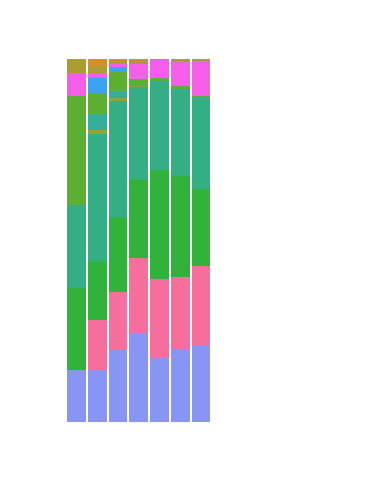

<Figure size 3840x2880 with 0 Axes>

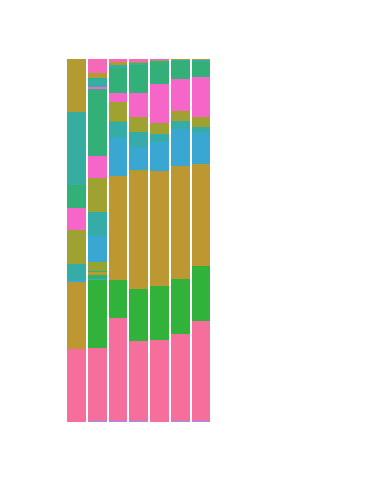

<Figure size 3840x2880 with 0 Axes>

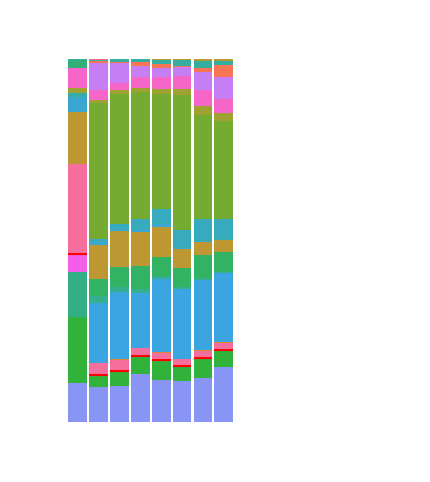

In [13]:
IDX_list_sub1 =    IDX_list_A1
IDX_list_sub2 =    IDX_list_A2
IDX_list_coal =    IDX_list_A6

IDX_list=IDX_list_sub1 
IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
df=Processed_sequences_synthetic.iloc[IDX_list_]
sub1_final=df.iloc[-1].values[1:]

IDX_list=IDX_list_sub2
IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
df=Processed_sequences_synthetic.iloc[IDX_list_]
sub2_final=df.iloc[-1].values[1:]

sub1_mask=(sub1_final>sub2_final)
sub2_mask=(sub2_final>sub1_final)

f=plot_timeseries_sub(IDX_list_sub1, sub1_mask)
f.savefig('Figure/Fig_1-3_timeseries_ex1_sub1.svg', bbox_inches='tight')

f=plot_timeseries_sub(IDX_list_sub2, sub2_mask)
f.savefig('Figure/Fig_1-3_timeseries_ex1_sub2.svg', bbox_inches='tight')

f=plot_timeseries_coal(IDX_list_coal, sub1_mask, sub2_mask, sub1_final, sub2_final)
f.savefig('Figure/Fig_1-3_timeseries_ex1_coal.svg', bbox_inches='tight')


[0.50890406 0.37382693 0.40146505 0.38336823 0.4422569  0.3810687
 0.41370349 0.39879838]


<Figure size 3840x2880 with 0 Axes>

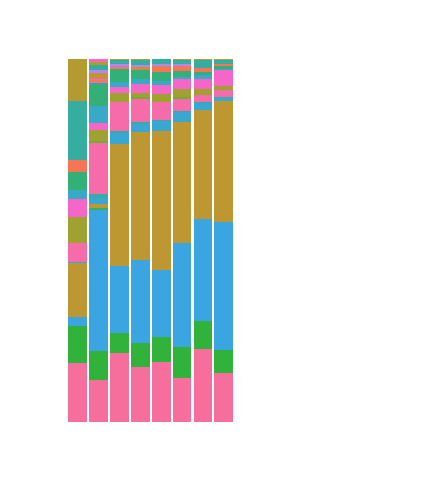

<Figure size 3840x2880 with 0 Axes>

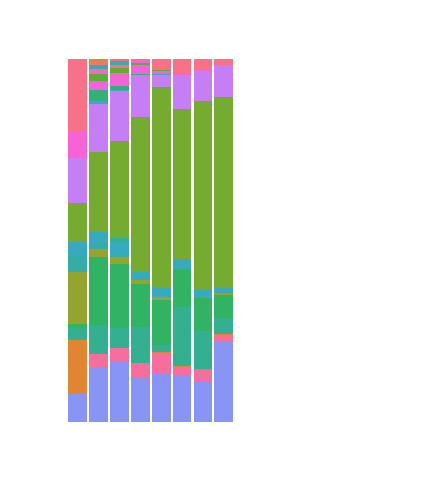

<Figure size 3840x2880 with 0 Axes>

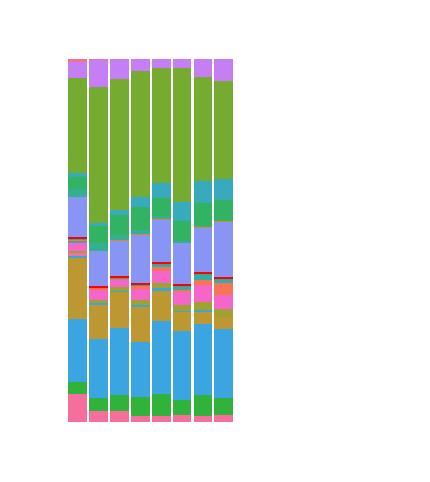

In [14]:
IDX_list_sub1 =    IDX_list_A4
IDX_list_sub2 =    IDX_list_A3
IDX_list_coal =    IDX_list_A6

IDX_list=IDX_list_sub1 
IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
df=Processed_sequences_synthetic.iloc[IDX_list_]
sub1_final=df.iloc[-1].values[1:]

IDX_list=IDX_list_sub2
IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
df=Processed_sequences_synthetic.iloc[IDX_list_]
sub2_final=df.iloc[-1].values[1:]

sub1_mask=(sub1_final>sub2_final)
sub2_mask=(sub2_final>sub1_final)

f=plot_timeseries_sub(IDX_list_sub1, sub1_mask)
f.savefig('Figure/Fig_1-3_timeseries_ex2_sub1.svg', bbox_inches='tight')

f=plot_timeseries_sub(IDX_list_sub2, sub2_mask)
f.savefig('Figure/Fig_1-3_timeseries_ex2_sub2.svg', bbox_inches='tight')

f=plot_timeseries_coal(IDX_list_coal, sub1_mask, sub2_mask, sub1_final, sub2_final)
f.savefig('Figure/Fig_1-3_timeseries_ex2_coal.svg', bbox_inches='tight')


medium 1
[0.50515543 0.11015749 0.05279671 0.16669813 0.10768266 0.12218996
 0.13421569]


<Figure size 3840x2880 with 0 Axes>

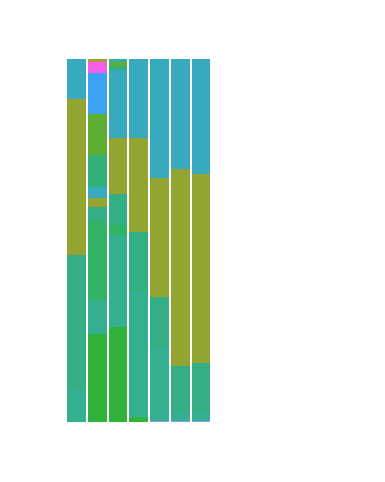

<Figure size 3840x2880 with 0 Axes>

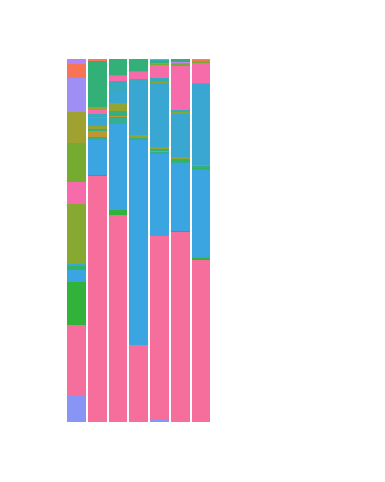

<Figure size 3840x2880 with 0 Axes>

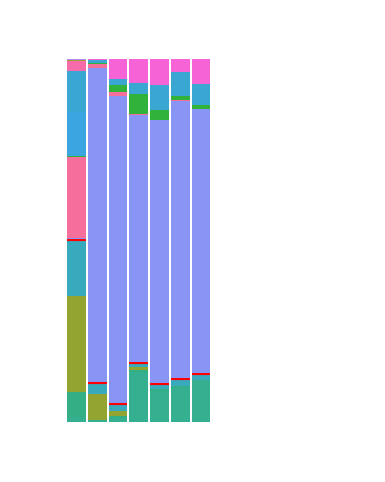

In [15]:
print("medium 1")
IDX_list_sub1 =    IDX_list_D2
IDX_list_sub2 =    IDX_list_D8
IDX_list_coal =    IDX_list_B12

IDX_list=IDX_list_sub1 
IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
df=Processed_sequences_synthetic.iloc[IDX_list_]
sub1_final=df.iloc[-1].values[1:]

IDX_list=IDX_list_sub2
IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
df=Processed_sequences_synthetic.iloc[IDX_list_]
sub2_final=df.iloc[-1].values[1:]

sub1_mask=(sub1_final>sub2_final)
sub2_mask=(sub2_final>sub1_final)

f=plot_timeseries_sub(IDX_list_sub1, sub1_mask)
f.savefig('Figure/Fig_1-3_timeseries_ex2_sub1.svg', bbox_inches='tight')

f=plot_timeseries_sub(IDX_list_sub2, sub2_mask)
f.savefig('Figure/Fig_1-3_timeseries_ex2_sub2.svg', bbox_inches='tight')

f=plot_timeseries_coal(IDX_list_coal, sub1_mask, sub2_mask, sub1_final, sub2_final)
f.savefig('Figure/Fig_1-3_timeseries_ex2_coal.svg', bbox_inches='tight')


medium 2
[0.48832656 0.3577035  0.11712278 0.20571382 0.21031673 0.48235595
 0.75214211]
[0.47259103 0.09770638 0.44322888 0.81511566 0.59999988 0.60096931
 0.69841509]


<Figure size 3840x2880 with 0 Axes>

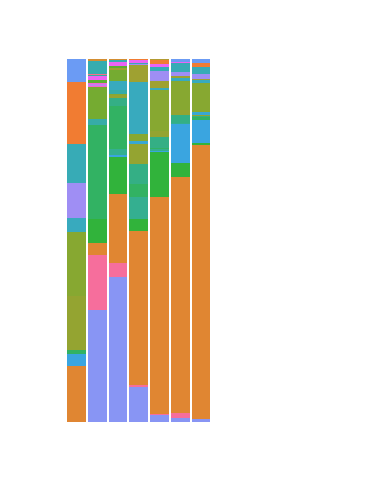

<Figure size 3840x2880 with 0 Axes>

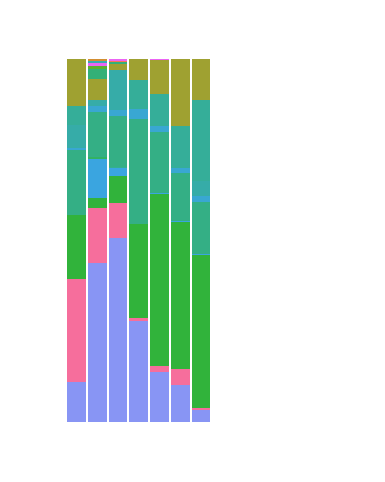

<Figure size 3840x2880 with 0 Axes>

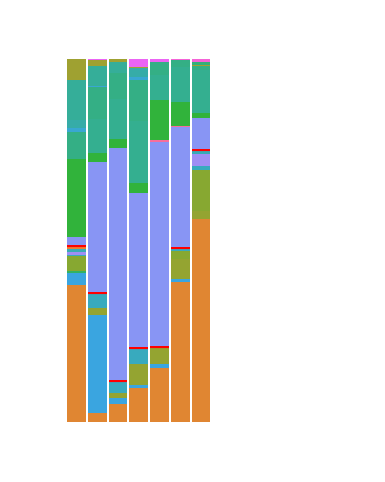

<Figure size 3840x2880 with 0 Axes>

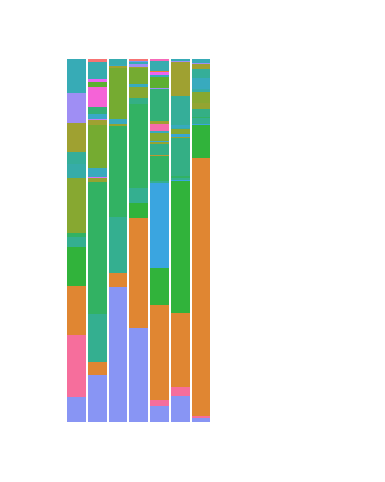

<Figure size 3840x2880 with 0 Axes>

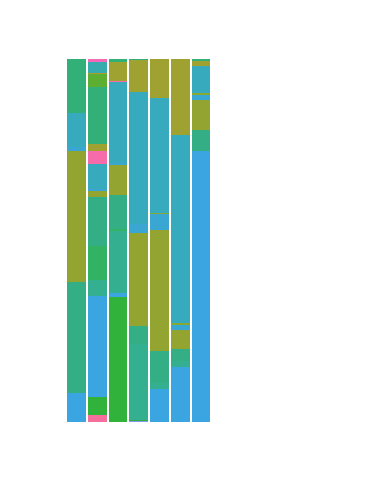

<Figure size 3840x2880 with 0 Axes>

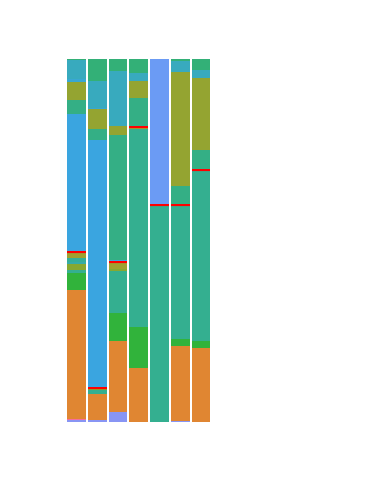

In [16]:
print("medium 2")

# G5+G6->D9
# G9+G10->D11

IDX_list_sub1 =    IDX_list_G6
IDX_list_sub2 =    IDX_list_G9
IDX_list_coal =    IDX_list_D9

IDX_list=IDX_list_sub1 
IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
df=Processed_sequences_synthetic.iloc[IDX_list_]
sub1_final=df.iloc[-1].values[1:]

IDX_list=IDX_list_sub2
IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
df=Processed_sequences_synthetic.iloc[IDX_list_]
sub2_final=df.iloc[-1].values[1:]

sub1_mask=(sub1_final>sub2_final)
sub2_mask=(sub2_final>sub1_final)

f=plot_timeseries_sub(IDX_list_sub1, sub1_mask)
f.savefig('Figure/Fig_1-3_timeseries_ex2_sub1.svg', bbox_inches='tight')

f=plot_timeseries_sub(IDX_list_sub2, sub2_mask)
f.savefig('Figure/Fig_1-3_timeseries_ex2_sub2.svg', bbox_inches='tight')

f=plot_timeseries_coal(IDX_list_coal, sub1_mask, sub2_mask, sub1_final, sub2_final)
f.savefig('Figure/Fig_1-3_timeseries_ex2_coal.svg', bbox_inches='tight')

IDX_list_sub1 =    IDX_list_G5
IDX_list_sub2 =    IDX_list_G10
IDX_list_coal =    IDX_list_D11

IDX_list=IDX_list_sub1 
IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
df=Processed_sequences_synthetic.iloc[IDX_list_]
sub1_final=df.iloc[-1].values[1:]

IDX_list=IDX_list_sub2
IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
df=Processed_sequences_synthetic.iloc[IDX_list_]
sub2_final=df.iloc[-1].values[1:]

sub1_mask=(sub1_final>sub2_final)
sub2_mask=(sub2_final>sub1_final)

f=plot_timeseries_sub(IDX_list_sub1, sub1_mask)
f.savefig('Figure/Fig_1-3_timeseries_ex2_sub1.svg', bbox_inches='tight')

f=plot_timeseries_sub(IDX_list_sub2, sub2_mask)
f.savefig('Figure/Fig_1-3_timeseries_ex2_sub2.svg', bbox_inches='tight')

f=plot_timeseries_coal(IDX_list_coal, sub1_mask, sub2_mask, sub1_final, sub2_final)
f.savefig('Figure/Fig_1-3_timeseries_ex2_coal.svg', bbox_inches='tight')


high 1


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (6, 1) + inhomogeneous part.

<Figure size 3840x2880 with 0 Axes>

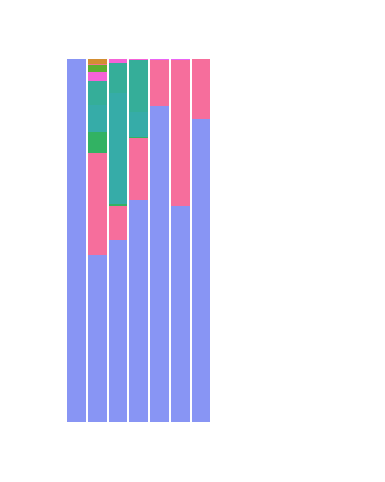

<Figure size 3840x2880 with 0 Axes>

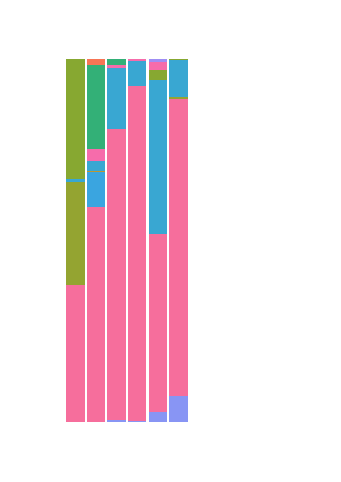

<Figure size 3840x2880 with 0 Axes>

In [17]:
print("high 1")

IDX_list_sub1 =    IDX_list_B1
IDX_list_sub2 =    IDX_list_B2
IDX_list_coal =    IDX_list_B4

IDX_list=IDX_list_sub1 
IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
df=Processed_sequences_synthetic.iloc[IDX_list_]
sub1_final=df.iloc[-1].values[1:]

IDX_list=IDX_list_sub2
IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
df=Processed_sequences_synthetic.iloc[IDX_list_]
sub2_final=df.iloc[-1].values[1:]

sub1_mask=(sub1_final>sub2_final)
sub2_mask=(sub2_final>sub1_final)

f=plot_timeseries_sub(IDX_list_sub1, sub1_mask)
f.savefig('Figure/Fig_1-3_timeseries_ex2_sub1.svg', bbox_inches='tight')

f=plot_timeseries_sub(IDX_list_sub2, sub2_mask)
f.savefig('Figure/Fig_1-3_timeseries_ex2_sub2.svg', bbox_inches='tight')

f=plot_timeseries_coal(IDX_list_coal, sub1_mask, sub2_mask, sub1_final, sub2_final)
f.savefig('Figure/Fig_1-3_timeseries_ex2_coal.svg', bbox_inches='tight')
